<a href="https://colab.research.google.com/github/sanchit-fintech/FinSight/blob/main/notebooks/01_data_collection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FinSight — Data Collection

## Notebook 01

### Objective

The objective of this notebook is to collect historical stock market data for selected companies and prepare the initial raw dataset for the FinSight project.

### Pipeline

Company Selection → Data Collection → Data Inspection → Raw Dataset Storage

### Data Source

Yahoo Finance

---

This notebook is the first stage of the FinSight data pipeline.

In [ ]:
# ============================================
# FINSIGHT — IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ============================================
# FINSIGHT — SELECT COMPANIES
# ============================================

companies = {
    "Reliance Industries": "RELIANCE.NS",
    "Tata Consultancy Services": "TCS.NS",
    "Infosys": "INFY.NS",
    "HDFC Bank": "HDFCBANK.NS",
    "ICICI Bank": "ICICIBANK.NS"
}

print("Selected companies:")

for company in companies:
    print("-", company)

Selected companies:
- Reliance Industries
- Tata Consultancy Services
- Infosys
- HDFC Bank
- ICICI Bank


In [ ]:
# ============================================
# FINSIGHT — DOWNLOAD RELIANCE STOCK DATA
# ============================================

# Define the stock ticker
ticker = "RELIANCE.NS"

# Download historical stock data from Yahoo Finance
reliance_data = yf.download(
    ticker,
    start="2020-01-01",
    end="2025-01-01"
)

# Display the first 20 rows
print("FIRST 20 ROWS OF RELIANCE STOCK DATA")
display(reliance_data.head(5))

# Display the last 10 rows
print("LAST 10 ROWS OF RELIANCE STOCK DATA")
display(reliance_data.tail(5))

# Display the size of the dataset
print("\nDataset Shape:", reliance_data.shape)

# Display basic information
print("\nDataset Columns:")
print(reliance_data.columns)

/tmp/ipykernel_1177/28613053.py:9: FutureWarning: YF.download() has changed argument auto_adjust default to True
  reliance_data = yf.download(
[*********************100%***********************]  1 of 1 completed

FIRST 20 ROWS OF RELIANCE STOCK DATA


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,672.216125,680.008790,670.390471,675.956609,14004468
2020-01-02,683.660278,686.176208,673.284921,673.284921,17710316
2020-01-03,684.484070,686.487896,678.183128,682.636062,20984698
2020-01-06,668.609253,680.364982,667.050708,676.847198,24519177
2020-01-07,678.895630,683.304036,673.952826,676.401934,16683622


LAST 10 ROWS OF RELIANCE STOCK DATA


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2024-12-24,1212.280762,1222.988340,1210.545745,1211.834663,6734917
2024-12-26,1206.133911,1217.188348,1203.853555,1213.767935,10016178
2024-12-27,1210.595459,1217.386785,1206.580087,1207.869004,7000397
2024-12-30,1200.333984,1212.726960,1197.756270,1205.985254,8818766
2024-12-31,1205.043213,1208.661986,1195.822913,1197.657049,6405475



Dataset Shape: (1238, 5)

Dataset Columns:
MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])


In [ ]:
# ============================================
# FINSIGHT — UNDERSTAND STOCK DATA
# ============================================

# Display the column names
print("DATASET COLUMNS:")
print(reliance_data.columns)

print("\n" + "=" * 50)

# Display information about the dataset
print("DATASET INFORMATION:")
reliance_data.info()

print("\n" + "=" * 50)

# Display statistical summary
print("STATISTICAL SUMMARY:")
display(reliance_data.describe())

DATASET COLUMNS:
MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])

DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1238 entries, 2020-01-01 to 2024-12-31
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   (Close, RELIANCE.NS)   1238 non-null   float64
 1   (High, RELIANCE.NS)    1238 non-null   float64
 2   (Low, RELIANCE.NS)     1238 non-null   float64
 3   (Open, RELIANCE.NS)    1238 non-null   float64
 4   (Volume, RELIANCE.NS)  1238 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.0 KB

STATISTICAL SUMMARY:


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
count,1238.000000,1238.000000,1238.000000,1238.000000,1.238000e+03
mean,1095.098189,1107.006456,1084.237083,1095.962059,1.951391e+07
std,230.477779,230.698651,230.092006,230.365314,1.612248e+07
min,393.662415,423.029567,389.921930,407.978604,1.705656e+06
25%,951.000839,962.121236,942.435859,951.571314,1.009199e+07
50%,1115.586731,1127.810074,1106.010391,1116.995479,1.425293e+07
75%,1219.325348,1232.958612,1207.933170,1219.190519,2.203644e+07
max,1581.824463,1589.630354,1566.607971,1585.332124,1.426834e+08


In [ ]:
# ============================================
# FINSIGHT — CHECK DATA QUALITY
# ============================================

# Check for missing values in each column
print("MISSING VALUES IN EACH COLUMN:")
print(reliance_data.isnull().sum())

print("\n" + "=" * 50)

# Check if the entire dataset contains any missing values
total_missing = reliance_data.isnull().sum().sum()

print("TOTAL MISSING VALUES:", total_missing)

print("\n" + "=" * 50)

# Display duplicate rows
duplicate_rows = reliance_data.duplicated().sum()

print("TOTAL DUPLICATE ROWS:", duplicate_rows)

MISSING VALUES IN EACH COLUMN:
Price   Ticker     
Close   RELIANCE.NS    0
High    RELIANCE.NS    0
Low     RELIANCE.NS    0
Open    RELIANCE.NS    0
Volume  RELIANCE.NS    0
dtype: int64

TOTAL MISSING VALUES: 0

TOTAL DUPLICATE ROWS: 0


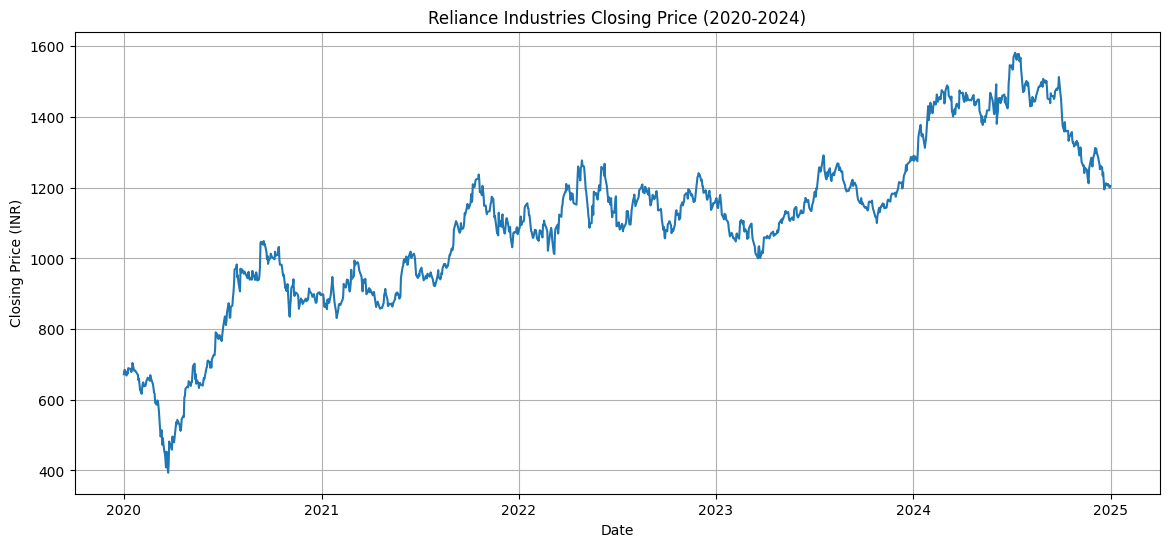

In [ ]:
# ============================================
# FINSIGHT — VISUALIZE RELIANCE STOCK PRICE
# ============================================

import matplotlib.pyplot as plt

# Create the graph
plt.figure(figsize=(14, 6))

plt.plot(
    reliance_data.index,
    reliance_data["Close"]
)

# Add title and labels
plt.title("Reliance Industries Closing Price (2020-2024)")
plt.xlabel("Date")
plt.ylabel("Closing Price (INR)")

# Add grid
plt.grid(True)

# Display the graph
plt.show()

In [ ]:
# ============================================
# FINSIGHT — BASIC STOCK INFORMATION
# ============================================

# Get the closing price column
close_prices = reliance_data["Close"]

# Calculate basic information
lowest_price = close_prices.min()
highest_price = close_prices.max()
average_price = close_prices.mean()

# Print the results
print("RELIANCE STOCK SUMMARY")
print("=" * 40)

print("Lowest Closing Price:", lowest_price)
print("Highest Closing Price:", highest_price)
print("Average Closing Price:", average_price)

RELIANCE STOCK SUMMARY
Lowest Closing Price: Ticker
RELIANCE.NS    393.662415
dtype: float64
Highest Closing Price: Ticker
RELIANCE.NS    1581.824463
dtype: float64
Average Closing Price: Ticker
RELIANCE.NS    1095.098189
dtype: float64


In [ ]:
# ============================================
# FINSIGHT — UNDERSTAND DATA STRUCTURE
# ============================================

# Print the complete column structure
print("COLUMN STRUCTURE:")
print(reliance_data.columns)

print("\nColumn levels:", reliance_data.columns.nlevels)

print("\nDataset preview:")
display(reliance_data.head())

COLUMN STRUCTURE:
MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS')],
           names=['Price', 'Ticker'])

Column levels: 2

Dataset preview:


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,672.216125,680.008790,670.390471,675.956609,14004468
2020-01-02,683.660278,686.176208,673.284921,673.284921,17710316
2020-01-03,684.484070,686.487896,678.183128,682.636062,20984698
2020-01-06,668.609253,680.364982,667.050708,676.847198,24519177
2020-01-07,678.895630,683.304036,673.952826,676.401934,16683622


In [ ]:
# ============================================
# FINSIGHT — CLEAN COLUMN STRUCTURE
# ============================================

# Check if columns have multiple levels
if reliance_data.columns.nlevels > 1:

    # Keep only the first level: Close, High, Low, Open, Volume
    reliance_data.columns = reliance_data.columns.get_level_values(0)

# Display the cleaned column names
print("CLEANED COLUMN NAMES:")
print(reliance_data.columns)

print("\nDATASET PREVIEW:")
display(reliance_data.head())

CLEANED COLUMN NAMES:
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

DATASET PREVIEW:


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-01,672.216125,680.008790,670.390471,675.956609,14004468
2020-01-02,683.660278,686.176208,673.284921,673.284921,17710316
2020-01-03,684.484070,686.487896,678.183128,682.636062,20984698
2020-01-06,668.609253,680.364982,667.050708,676.847198,24519177
2020-01-07,678.895630,683.304036,673.952826,676.401934,16683622


In [ ]:
# ============================================
# FINSIGHT — CALCULATE DAILY RETURNS
# ============================================

# Calculate daily percentage return
reliance_data["Daily_Return"] = (
    reliance_data["Close"].pct_change() * 100
)

# Display the first 10 rows
display(reliance_data[["Close", "Daily_Return"]].head(10))

Price,Close,Daily_Return
Date,,
2020-01-01,672.216125,NaN
2020-01-02,683.660278,1.702451
2020-01-03,684.484070,0.120497
2020-01-06,668.609253,-2.319238
2020-01-07,678.895630,1.538474
2020-01-08,673.796997,-0.751019
2020-01-09,689.315552,2.303150
2020-01-10,689.159668,-0.022614
2020-01-13,687.400757,-0.255225


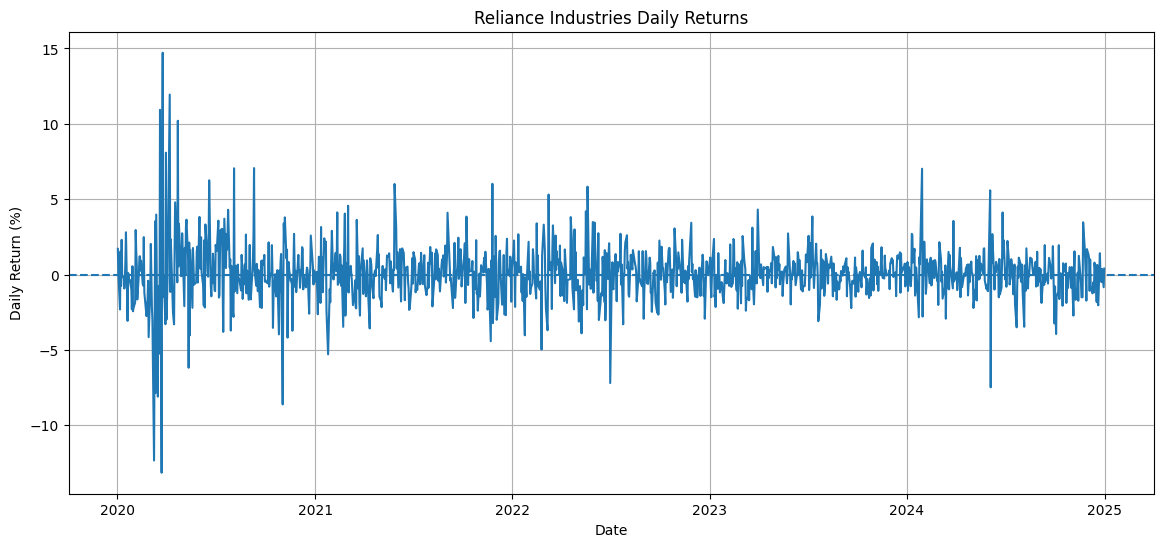

In [ ]:
# ============================================
# FINSIGHT — VISUALIZE DAILY RETURNS
# ============================================

# Create graph
plt.figure(figsize=(14, 6))

# Plot daily returns
plt.plot(
    reliance_data.index,
    reliance_data["Daily_Return"]
)

# Add a horizontal line at 0%
plt.axhline(y=0, linestyle="--")

# Add title and labels
plt.title("Reliance Industries Daily Returns")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")

# Add grid
plt.grid(True)

# Display graph
plt.show()

In [ ]:
# ============================================
# FINSIGHT — CALCULATE 20-DAY VOLATILITY
# ============================================

# Calculate 20-day rolling volatility
reliance_data["Volatility_20D"] = (
    reliance_data["Daily_Return"]
    .rolling(window=20)
    .std()
)

# Confirm that the column was created
print("VOLATILITY COLUMN CREATED SUCCESSFULLY!")

print("\nCurrent columns:")
print(reliance_data.columns)

# Display some data
display(
    reliance_data[
        ["Close", "Daily_Return", "Volatility_20D"]
    ].head(25)
)

VOLATILITY COLUMN CREATED SUCCESSFULLY!

Current columns:
Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Daily_Return',
       'Volatility_20D'],
      dtype='object', name='Price')


Price,Close,Daily_Return,Volatility_20D
Date,,,
2020-01-01,672.216125,NaN,NaN
2020-01-02,683.660278,1.702451,NaN
2020-01-03,684.484070,0.120497,NaN
2020-01-06,668.609253,-2.319238,NaN
2020-01-07,678.895630,1.538474,NaN
2020-01-08,673.796997,-0.751019,NaN
2020-01-09,689.315552,2.303150,NaN
2020-01-10,689.159668,-0.022614,NaN
2020-01-13,687.400757,-0.255225,NaN


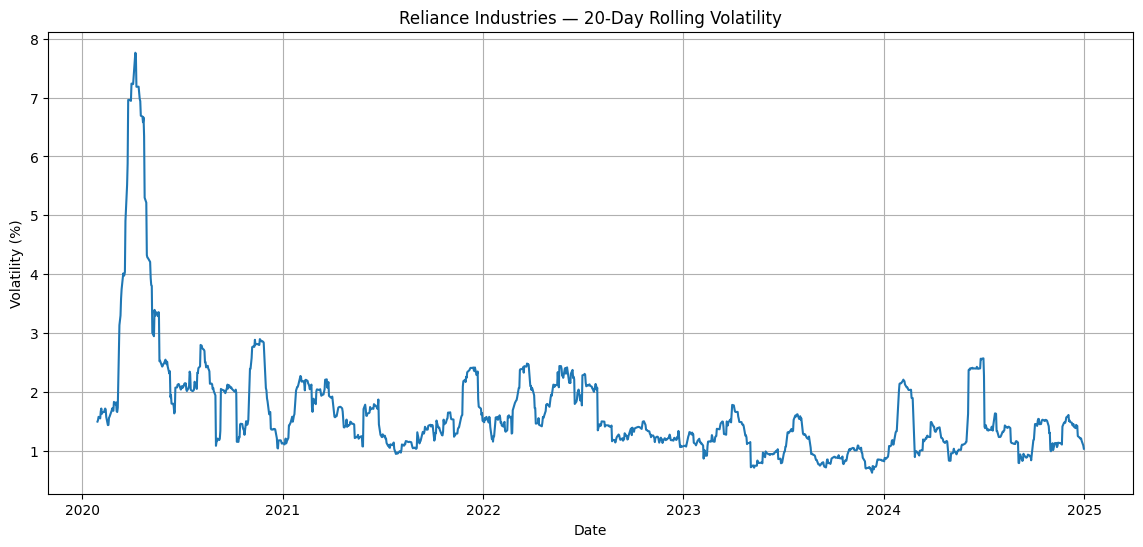

In [ ]:
# ============================================
# FINSIGHT — VISUALIZE 20-DAY VOLATILITY
# ============================================

plt.figure(figsize=(14, 6))

plt.plot(
    reliance_data.index,
    reliance_data["Volatility_20D"]
)

plt.title("Reliance Industries — 20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility (%)")

plt.grid(True)

plt.show()

In [ ]:
# ============================================
# STOCK ANALYZER — MOVING AVERAGES
# ============================================

# Calculate 20-day moving average
reliance_data["MA_20"] = (
    reliance_data["Close"]
    .rolling(window=20)
    .mean()
)

# Calculate 50-day moving average
reliance_data["MA_50"] = (
    reliance_data["Close"]
    .rolling(window=50)
    .mean()
)

# Display the first 55 rows
display(
    reliance_data[
        ["Close", "MA_20", "MA_50"]
    ].head(55)
)

Price,Close,MA_20,MA_50
Date,,,
2020-01-01,672.216125,NaN,NaN
2020-01-02,683.660278,NaN,NaN
2020-01-03,684.484070,NaN,NaN
2020-01-06,668.609253,NaN,NaN
2020-01-07,678.895630,NaN,NaN
2020-01-08,673.796997,NaN,NaN
2020-01-09,689.315552,NaN,NaN
2020-01-10,689.159668,NaN,NaN
2020-01-13,687.400757,NaN,NaN


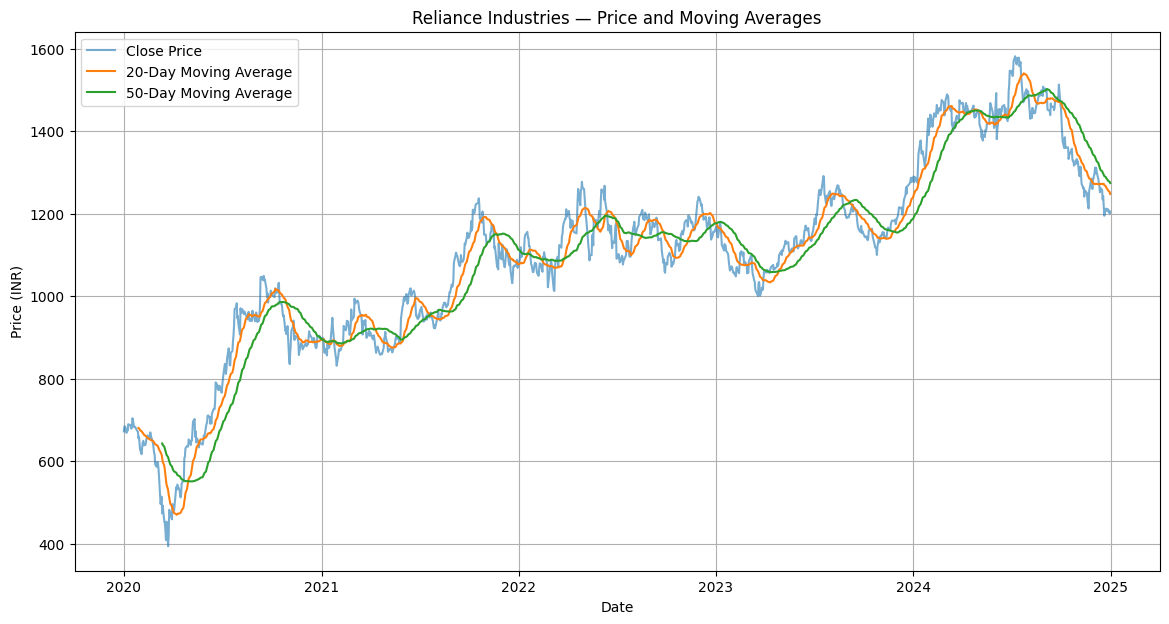

In [ ]:
# ============================================
# STOCK ANALYZER — MOVING AVERAGE VISUALIZATION
# ============================================

# Create graph
plt.figure(figsize=(14, 7))

# Plot actual closing price
plt.plot(
    reliance_data.index,
    reliance_data["Close"],
    label="Close Price",
    alpha=0.6
)

# Plot 20-day moving average
plt.plot(
    reliance_data.index,
    reliance_data["MA_20"],
    label="20-Day Moving Average"
)

# Plot 50-day moving average
plt.plot(
    reliance_data.index,
    reliance_data["MA_50"],
    label="50-Day Moving Average"
)

# Add title and labels
plt.title("Reliance Industries — Price and Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price (INR)")

# Add legend
plt.legend()

# Add grid
plt.grid(True)

# Display graph
plt.show()

In [ ]:
# ============================================
# STOCK ANALYZER — RSI STEP 1
# SEPARATE GAINS AND LOSSES
# ============================================

# Calculate daily price change
reliance_data["Price_Change"] = (
    reliance_data["Close"].diff()
)

# Create Gain column
reliance_data["Gain"] = (
    reliance_data["Price_Change"].clip(lower=0)
)

# Create Loss column
reliance_data["Loss"] = (
    -reliance_data["Price_Change"].clip(upper=0)
)

# Display the result
display(
    reliance_data[
        ["Close", "Price_Change", "Gain", "Loss"]
    ].head(10)
)

Price,Close,Price_Change,Gain,Loss
Date,,,,
2020-01-01,672.216125,NaN,NaN,NaN
2020-01-02,683.660278,11.444153,11.444153,-0.000000
2020-01-03,684.484070,0.823792,0.823792,-0.000000
2020-01-06,668.609253,-15.874817,0.000000,15.874817
2020-01-07,678.895630,10.286377,10.286377,-0.000000
2020-01-08,673.796997,-5.098633,0.000000,5.098633
2020-01-09,689.315552,15.518555,15.518555,-0.000000
2020-01-10,689.159668,-0.155884,0.000000,0.155884
2020-01-13,687.400757,-1.758911,0.000000,1.758911


In [ ]:
# ============================================
# STOCK ANALYZER — RSI STEP 2
# CALCULATE AVERAGE GAIN AND LOSS
# ============================================

# Calculate 14-day average gain
reliance_data["Avg_Gain_14"] = (
    reliance_data["Gain"]
    .rolling(window=14)
    .mean()
)

# Calculate 14-day average loss
reliance_data["Avg_Loss_14"] = (
    reliance_data["Loss"]
    .rolling(window=14)
    .mean()
)

# Display the result
display(
    reliance_data[
        ["Gain", "Loss", "Avg_Gain_14", "Avg_Loss_14"]
    ].head(20)
)

Price,Gain,Loss,Avg_Gain_14,Avg_Loss_14
Date,,,,
2020-01-01,NaN,NaN,NaN,NaN
2020-01-02,11.444153,-0.000000,NaN,NaN
2020-01-03,0.823792,-0.000000,NaN,NaN
2020-01-06,0.000000,15.874817,NaN,NaN
2020-01-07,10.286377,-0.000000,NaN,NaN
2020-01-08,0.000000,5.098633,NaN,NaN
2020-01-09,15.518555,-0.000000,NaN,NaN
2020-01-10,0.000000,0.155884,NaN,NaN
2020-01-13,0.000000,1.758911,NaN,NaN


In [ ]:
# ============================================
# STOCK ANALYZER — RSI STEP 3
# CALCULATE RS AND RSI
# ============================================

# Calculate Relative Strength (RS)
reliance_data["RS"] = (
    reliance_data["Avg_Gain_14"] /
    reliance_data["Avg_Loss_14"]
)

# Calculate RSI
reliance_data["RSI_14"] = (
    100 - (100 / (1 + reliance_data["RS"]))
)

# Display the result
display(
    reliance_data[
        ["Avg_Gain_14", "Avg_Loss_14", "RS", "RSI_14"]
    ].head(25)
)

Price,Avg_Gain_14,Avg_Loss_14,RS,RSI_14
Date,,,,
2020-01-01,NaN,NaN,NaN,NaN
2020-01-02,NaN,NaN,NaN,NaN
2020-01-03,NaN,NaN,NaN,NaN
2020-01-06,NaN,NaN,NaN,NaN
2020-01-07,NaN,NaN,NaN,NaN
2020-01-08,NaN,NaN,NaN,NaN
2020-01-09,NaN,NaN,NaN,NaN
2020-01-10,NaN,NaN,NaN,NaN
2020-01-13,NaN,NaN,NaN,NaN


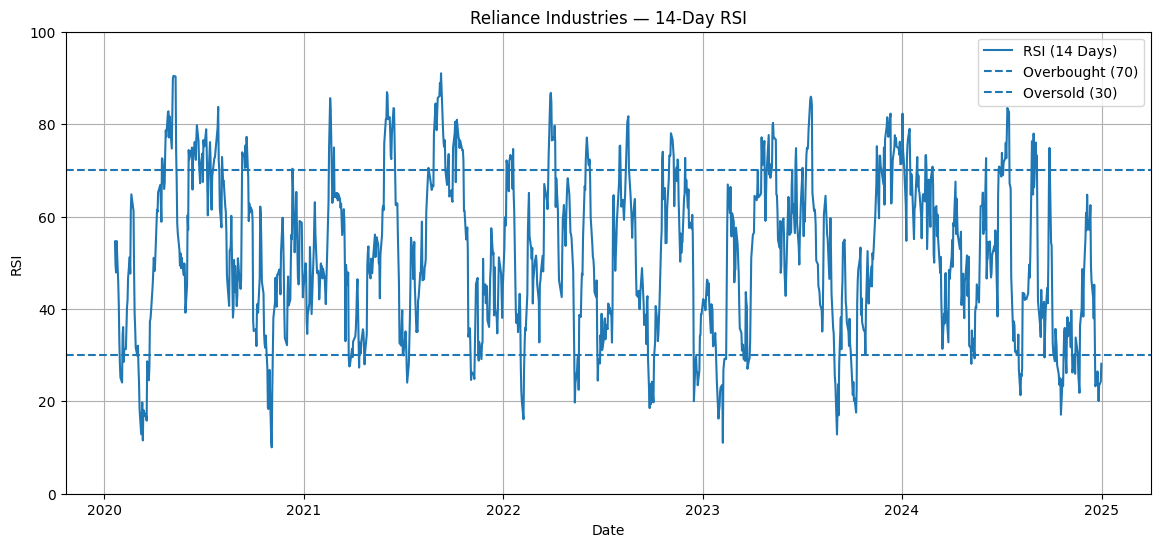

In [ ]:
# ============================================
# STOCK ANALYZER — RSI VISUALIZATION
# ============================================

# Create graph
plt.figure(figsize=(14, 6))

# Plot RSI
plt.plot(
    reliance_data.index,
    reliance_data["RSI_14"],
    label="RSI (14 Days)"
)

# Add overbought line
plt.axhline(y=70, linestyle="--", label="Overbought (70)")

# Add oversold line
plt.axhline(y=30, linestyle="--", label="Oversold (30)")

# Add title and labels
plt.title("Reliance Industries — 14-Day RSI")
plt.xlabel("Date")
plt.ylabel("RSI")

# Set RSI range
plt.ylim(0, 100)

# Add legend and grid
plt.legend()
plt.grid(True)

# Display graph
plt.show()

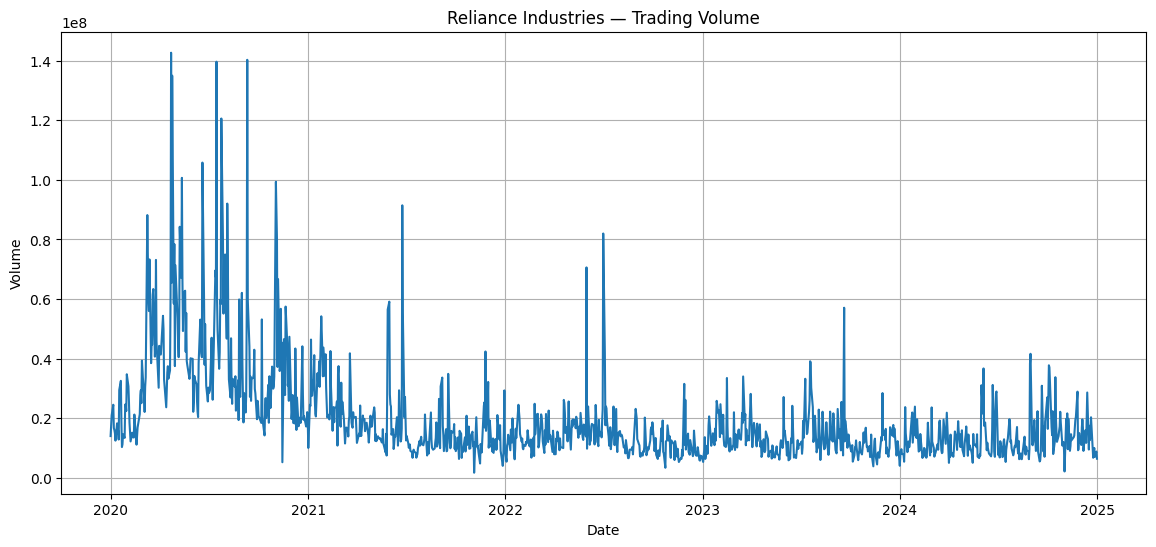

In [ ]:
# ============================================
# STOCK ANALYZER — VOLUME ANALYSIS
# ============================================

# Create graph
plt.figure(figsize=(14, 6))

# Plot trading volume
plt.plot(
    reliance_data.index,
    reliance_data["Volume"]
)

# Add title and labels
plt.title("Reliance Industries — Trading Volume")
plt.xlabel("Date")
plt.ylabel("Volume")

# Add grid
plt.grid(True)

# Display graph
plt.show()

In [ ]:
# ============================================
# STOCK ANALYZER — VOLUME MOVING AVERAGE
# ============================================

# Calculate 20-day average trading volume
reliance_data["Volume_MA_20"] = (
    reliance_data["Volume"]
    .rolling(window=20)
    .mean()
)

# Display Volume and its moving average
display(
    reliance_data[
        ["Volume", "Volume_MA_20"]
    ].head(25)
)

Price,Volume,Volume_MA_20
Date,,
2020-01-01,14004468,NaN
2020-01-02,17710316,NaN
2020-01-03,20984698,NaN
2020-01-06,24519177,NaN
2020-01-07,16683622,NaN
2020-01-08,16047902,NaN
2020-01-09,14982742,NaN
2020-01-10,12478359,NaN
2020-01-13,18282382,NaN


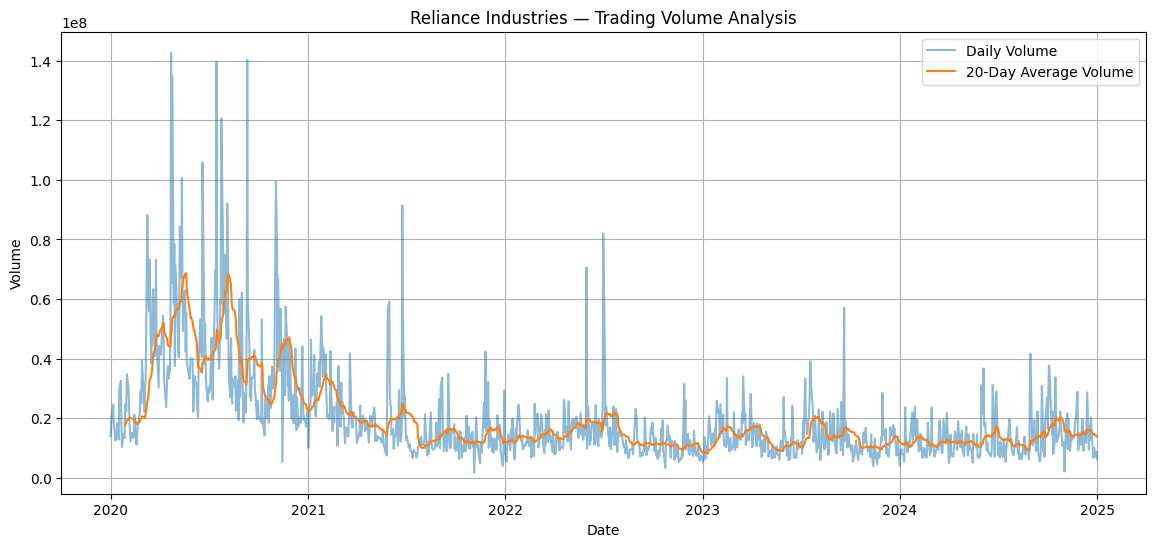

In [ ]:
# ============================================
# STOCK ANALYZER — VOLUME VISUALIZATION
# ============================================

# Create graph
plt.figure(figsize=(14, 6))

# Plot actual trading volume
plt.plot(
    reliance_data.index,
    reliance_data["Volume"],
    label="Daily Volume",
    alpha=0.5
)

# Plot 20-day average volume
plt.plot(
    reliance_data.index,
    reliance_data["Volume_MA_20"],
    label="20-Day Average Volume"
)

# Add title and labels
plt.title("Reliance Industries — Trading Volume Analysis")
plt.xlabel("Date")
plt.ylabel("Volume")

# Add legend and grid
plt.legend()
plt.grid(True)

# Display graph
plt.show()

In [ ]:
# ============================================
# STOCK ANALYZER — VOLUME RATIO
# ============================================

# Compare today's volume with the 20-day average volume
reliance_data["Volume_Ratio"] = (
    reliance_data["Volume"] /
    reliance_data["Volume_MA_20"]
)

# Display the relevant columns
display(
    reliance_data[
        ["Volume", "Volume_MA_20", "Volume_Ratio"]
    ].head(25)
)

Price,Volume,Volume_MA_20,Volume_Ratio
Date,,,
2020-01-01,14004468,NaN,NaN
2020-01-02,17710316,NaN,NaN
2020-01-03,20984698,NaN,NaN
2020-01-06,24519177,NaN,NaN
2020-01-07,16683622,NaN,NaN
2020-01-08,16047902,NaN,NaN
2020-01-09,14982742,NaN,NaN
2020-01-10,12478359,NaN,NaN
2020-01-13,18282382,NaN,NaN
